# Kapitel 4 - Koduppgift 14

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# läs in data
iris = load_iris()
print(iris.DESCR)
print("Klasser:", iris.target_names)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [3]:
X, y = load_iris(return_X_y=True, as_frame=True)

# väljer bara två variabler för att göra det enklare
X = X[['sepal length (cm)', 'sepal width (cm)']]

In [4]:
# dela upp data i träningsdata, valideringsdata och testdata
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36, stratify=y_train_full)

print("Träningsdata:", X_train.shape[0], "observationer")
print("Valideringsdata:", X_val.shape[0], "observationer")
print("Testdata:", X_test.shape[0], "observationer")
print()

Träningsdata: 84 observationer
Valideringsdata: 36 observationer
Testdata: 30 observationer



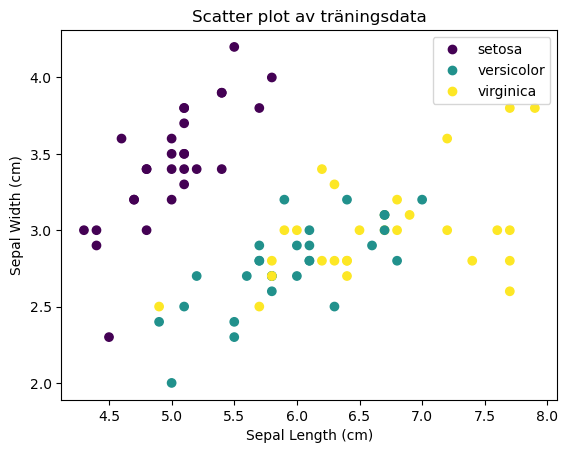

In [5]:
classes = ['setosa', 'versicolor', 'virginica']

scatter = plt.scatter(
    X_train['sepal length (cm)'],
    X_train['sepal width (cm)'],
    c=y_train
)

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Scatter plot av träningsdata')
plt.legend(handles=scatter.legend_elements()[0], labels=classes)
plt.show()

In [6]:
# d) skapa och träna modellen
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [7]:
# f) träna om modellen på all träningsdata
lr.fit(X_train_full, y_train_full)

# g) testa modellen på osedd testdata
y_test_pred = lr.predict(X_test)

print("Utvärdering på testdata:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("Classification report:")
print(classification_report(y_test, y_test_pred))

Utvärdering på testdata:
Accuracy: 0.7666666666666667
Confusion matrix:
[[10  0  0]
 [ 0  6  4]
 [ 0  3  7]]
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.67      0.60      0.63        10
           2       0.64      0.70      0.67        10

    accuracy                           0.77        30
   macro avg       0.77      0.77      0.77        30
weighted avg       0.77      0.77      0.77        30



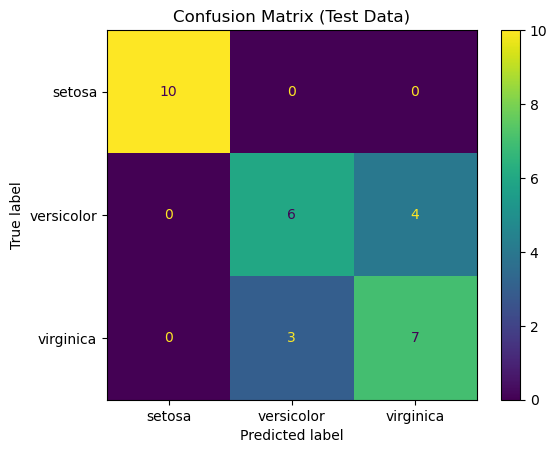

In [8]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()

plt.title("Confusion Matrix (Test Data)")
plt.show()